# Multi-Pattern Strategy Backtest Analysis

This notebook demonstrates how to run the multi-pattern confluence strategy
using the backtesting.py framework and generate visualization reports.

---

## Quick Configuration Guide

Modify the `CONFIG` dictionary in Section 1 to customize:
- Data source and date range
- Backtest parameters (capital, commission, risk)
- Strategy parameters (confidence threshold, position limits)
- Output settings

---

## 1. Configuration Section

**Modify parameters below to customize the backtest.**

In [1]:
# ============================================================
# CONFIGURATION - Modify these parameters to customize analysis
# ============================================================

CONFIG = {
    # ----------------------------------------------------------
    # Data Configuration
    # ----------------------------------------------------------
    'data': {
        'file': 'SPY_daily.csv',              # Data file name
        'directory': 'data/raw',              # Data directory
        'start_date': None,                   # Start date filter (None = all)
        'end_date': None,                     # End date filter (None = all)
        'columns': ['Open', 'High', 'Low', 'Close', 'Volume'],
    },
    
    # ----------------------------------------------------------
    # Backtest Configuration
    # ----------------------------------------------------------
    'backtest': {
        'initial_equity': 100000,             # Starting capital
        'commission': 0.001,                  # Commission rate (0.1%)
        'exclusive_orders': True,            # Close positions before opening new
    },
    
    # ----------------------------------------------------------
    # Strategy Configuration
    # ----------------------------------------------------------
    'strategy': {
        'min_confidence': 0.55,              # Minimum signal confidence
        'risk_per_trade': 0.02,              # Risk per trade (2%)
        'max_open_positions': 3,             # Maximum concurrent positions
    },
    
    # ----------------------------------------------------------
    # Output Configuration
    # ----------------------------------------------------------
    'output': {
        'directory': 'reports',              # Output directory
        'save_plots': True,                  # Save plots to disk
        'show_plots': True,                  # Display plots in notebook
        'dpi': 150,                          # Plot resolution
    },
}

---

## 2. Setup and Imports

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Setup project root FIRST (before any src imports)
# Try different possible project root locations
candidates = [
    Path("..").resolve(),
    Path(".").resolve(),
]
for root in candidates:
    if (root / "src").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        project_root = root
        break
else:
    project_root = Path(".").resolve()
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

# Import notebook helpers
from src.utils.notebook_helpers import (
    load_price_data,
    print_data_summary,
    print_backtest_summary,
    get_output_path,
    create_runner_kwargs,
    create_strategy_kwargs,
    calculate_performance_metrics,
    calculate_trade_statistics,
    create_equity_curve_plot,
    create_drawdown_plot,
)

# Standard imports
import pandas as pd
import numpy as np
from datetime import datetime

# Import backtesting.py integration
from src.strategies.backtest_py import BacktestPyRunner, MultiPatternStrategy, MultiPatternStrategySimple

# Import visualization
from src.visualization import ReportGenerator, ChartGenerator, TearsheetGenerator

print("✅ Imports successful!")
print(f"Project root: {project_root}")

Loading BokehJS ...

✅ Imports successful!
Project root: C:\Dev\projects\investment_trying


---

## 3. Load Data

In [3]:
# Load data using helper function
df = load_price_data(CONFIG, project_root)

# Display data summary
print_data_summary(df, title="SPY Daily Data Summary")

📊 SPY Daily Data Summary
Date Range: 2015-01-02 to 2024-12-31
Total Trading Days: 2,516
Years of Data: 10.0

Columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Data shape: (2516, 5)

First 5 rows:
                  Open        High         Low       Close     Volume
Date                                                                 
2015-01-02  171.378508  171.793709  169.551612  170.589615  121465900
2015-01-05  169.543303  169.709381  167.201575  167.508820  169632600
2015-01-06  167.816066  168.339223  165.133869  165.931061  209151400
2015-01-07  167.259737  168.339263  166.811325  167.998795  125346700
2015-01-08  169.410444  171.195817  169.393845  170.979904  147217800

📈 Price Statistics:
          Open     High      Low    Close
count  2516.00  2516.00  2516.00  2516.00
mean    310.27   311.95   308.44   310.31
std     114.48   115.04   113.85   114.49
min     154.54   156.03   152.88   154.98
25%     212.24   212.82   211.43   212.17
50%     273.24   273.96   272.21   273

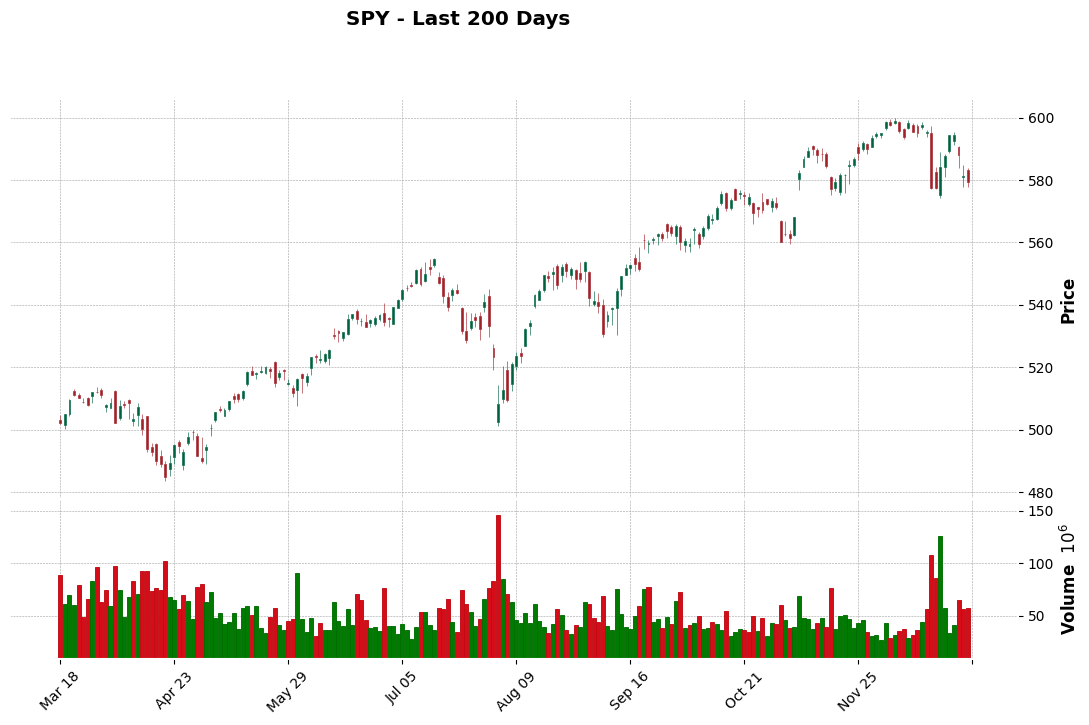

In [4]:
# Visualize price data
import mplfinance as mpf

mpf.plot(df.tail(200), type='candle', style='charles', 
         title='SPY - Last 200 Days', volume=True, figsize=(14, 8))

---

## 4. Run Backtest

In [5]:
# Initialize runner with config
runner = BacktestPyRunner(
    data=df,
    **create_runner_kwargs(CONFIG)
)

print("✅ Backtest runner initialized")
print(f"  Initial equity: ${CONFIG['backtest']['initial_equity']:,.0f}")
print(f"  Commission: {CONFIG['backtest']['commission']*100:.2f}%")

✅ Backtest runner initialized
  Initial equity: $100,000
  Commission: 0.10%


In [6]:
# Run with simplified strategy for faster backtesting
strategy_kwargs = create_strategy_kwargs(CONFIG)

print("🚀 Running backtest...")
print(f"  Strategy: MultiPatternStrategySimple")
print(f"  Min confidence: {strategy_kwargs['min_confidence']}")
print(f"  Risk per trade: {strategy_kwargs['risk_per_trade']*100:.1f}%")
print(f"  Max positions: {strategy_kwargs['max_open_positions']}")

results = runner.run(
    strategy_class=MultiPatternStrategySimple,
    **strategy_kwargs
)

print("\n✅ Backtest complete!")

🚀 Running backtest...
  Strategy: MultiPatternStrategySimple
  Min confidence: 0.55
  Risk per trade: 2.0%
  Max positions: 3
Running backtest on 2516 bars...


Backtest.run:   0%|          | 0/2515 [00:00<?, ?bar/s]


BACKTEST SUMMARY
Start Date: 2015-01-02 00:00:00
End Date: 2024-12-31 00:00:00
Duration: 3651 days 00:00:00

Initial Capital: $100,000.00
Final Equity: $103,050.13
Final Return: 3.05%

Total Trades: 44
Win Rate: 47.73%
Best Trade: 21.08%
Worst Trade: -14.72%
Avg Trade: 0.63%

Max Drawdown: -4.36%
Sharpe Ratio: 0.21
Sortino Ratio: 0.27
Calmar Ratio: 0.07


✅ Backtest complete!


In [7]:
# Get detailed trades
trades_df = runner.get_trades()
print(f"\nTotal trades: {len(trades_df)}")
if len(trades_df) > 0:
    display(trades_df.head(10))


Total trades: 0


In [8]:
# Get equity curve
equity_curve = runner.get_equity_curve()
print(f"Equity curve shape: {equity_curve.shape}")
equity_curve.head()

Equity curve shape: (2516, 3)


,Equity,DrawdownPct,DrawdownDuration
Date,,,
2015-01-02,100000.0,0.0,NaT
2015-01-05,100000.0,0.0,NaT
2015-01-06,100000.0,0.0,NaT
2015-01-07,100000.0,0.0,NaT
2015-01-08,100000.0,0.0,NaT


---

## 5. Generate Reports

In [9]:
# Generate comprehensive report
files = runner.generate_report(
    title="Multi-Pattern Strategy",
    include_plot=True
)

print("\n📁 Generated files:")
for name, path in files.items():
    print(f"  {name}: {path}")

Generating tearsheet...


Generating plot...


Report generated: 2 files

📁 Generated files:
  tearsheet: reports\multi-pattern_strategy_tearsheet.html
  plot: reports\multi-pattern_strategy_plot.html


In [10]:
# Display tearsheet (opens in browser)
output_dir = get_output_path(CONFIG, project_root)
runner.plot(filename=str(output_dir / 'multi_pattern_plot.html'))

---

## 6. Parameter Optimization (Optional)

Uncomment the cell below to run parameter optimization.

In [11]:
# Optimize parameters (this may take a while)
# Uncomment to run optimization

# optimized_results = runner.optimize(
#     strategy_class=MultiPatternStrategySimple,
#     max_tries=50,
#     min_confidence=[0.50, 0.55, 0.60, 0.65],
#     risk_per_trade=[0.01, 0.02, 0.03],
#     max_open_positions=[2, 3, 5]
# )

---

## 7. Analyze Results

In [12]:
# Get backtest statistics
stats = runner.get_stats()

# Print summary using helper function
print_backtest_summary(stats, title="Multi-Pattern Strategy Performance")

📈 Multi-Pattern Strategy Performance

Returns:
  Total Return: 3.05%
  Buy & Hold Return: 239.57%
  Annual Return: 0.30%

Risk Metrics:
  Max Drawdown: -4.36%
  Sharpe Ratio: 0.21
  Sortino Ratio: 0.27
  Calmar Ratio: 0.07

Trade Statistics:
  Total Trades: 44
  Win Rate: 47.73%
  Best Trade: 21.08%
  Worst Trade: -14.72%
  Avg Trade: 0.63%
  Max Trade Duration: 904 days 00:00:00
  Avg Trade Duration: 48 days 00:00:00


In [13]:
# Analyze trade distribution
if len(trades_df) > 0:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # PnL distribution
    axes[0, 0].hist(trades_df['pnl'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(x=0, color='red', linestyle='--', label='Break-even')
    axes[0, 0].set_title('Trade PnL Distribution')
    axes[0, 0].set_xlabel('PnL ($)')
    axes[0, 0].legend()
    
    # Win/Loss by direction
    direction_counts = trades_df.groupby(['direction', trades_df['pnl'] > 0]).size().unstack(fill_value=0)
    direction_counts.plot(kind='bar', ax=axes[0, 1], color=['red', 'green'])
    axes[0, 1].set_title('Win/Loss by Direction')
    axes[0, 1].set_xlabel('Direction')
    axes[0, 1].legend(['Loss', 'Win'])
    
    # Equity curve
    axes[1, 0].plot(equity_curve.index, equity_curve['Equity'])
    axes[1, 0].set_title('Equity Curve')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Equity ($)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Drawdown
    equity = equity_curve['Equity']
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max * 100
    axes[1, 1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
    axes[1, 1].set_title('Drawdown')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Drawdown (%)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save if configured
    if CONFIG['output']['save_plots']:
        save_path = get_output_path(CONFIG, project_root, 'multi_pattern_analysis.png')
        fig.savefig(save_path, dpi=CONFIG['output']['dpi'], bbox_inches='tight')
    
    if CONFIG['output']['show_plots']:
        plt.show()
    else:
        plt.close()

---

## 8. Summary Statistics

In [14]:
# Calculate additional metrics
if len(equity_curve) > 0:
    equity_series = equity_curve['Equity']
    metrics = calculate_performance_metrics(equity_series)
    
    print("\n" + "="*60)
    print("📊 DETAILED PERFORMANCE METRICS")
    print("="*60)
    for key, value in metrics.items():
        print(f"  {key}: {value}")
    print("="*60)

# Trade statistics
if len(trades_df) > 0:
    trade_stats = calculate_trade_statistics(trades_df)
    
    print("\n📊 TRADE STATISTICS:")
    for key, value in trade_stats.items():
        print(f"  {key}: {value}")


📊 DETAILED PERFORMANCE METRICS
  Total Return (%): 3.05
  Annual Return (%): 0.3
  Volatility (%): 1.46
  Sharpe Ratio: -1.16
  Sortino Ratio: -0.99
  Calmar Ratio: 0.07
  Max Drawdown (%): -4.36
